# Airplane Crashes & Fatalities (1908–2023)

## 1. Data Import & Cleaning

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

# Load dataset
df = pd.read_csv('Airplane_Crashes_and_Fatalities_Since_1908_t0_2023.csv',
                 encoding='latin1')

print('Shape:', df.shape)
print('\nColumns:', df.columns.tolist())
df.head(3)

Shape: (4998, 17)

Columns: ['Date', 'Time', 'Location', 'Operator', 'Flight #', 'Route', 'AC Type', 'Registration', 'cn/ln', 'Aboard', 'Aboard Passangers', 'Aboard Crew', 'Fatalities', 'Fatalities Passangers', 'Fatalities Crew', 'Ground', 'Summary']


,Date,Time,Location,Operator,Flight #,Route,AC Type,Registration,cn/ln,Aboard,Aboard Passangers,Aboard Crew,Fatalities,Fatalities Passangers,Fatalities Crew,Ground,Summary
0,9/17/1908,17:18,"Fort Myer, Virginia",Military - U.S. Army,NaN,Demonstration,Wright Flyer III,NaN,1,2.0,1.0,1.0,1.0,1.0,0.0,0.0,"During a demonstration flight, a U.S. Army fly..."
1,9/7/1909,NaN,"Juvisy-sur-Orge, France",NaN,NaN,Air show,Wright Byplane,SC1,NaN,1.0,0.0,1.0,1.0,0.0,0.0,0.0,Eugene Lefebvre was the first pilot to ever be...
2,7/12/1912,6:30,"Atlantic City, New Jersey",Military - U.S. Navy,NaN,Test flight,Dirigible,NaN,NaN,5.0,0.0,5.0,5.0,0.0,5.0,0.0,First U.S. dirigible Akron exploded just offsh...


In [2]:
# Convert Date to datetime
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Year'] = df['Date'].dt.year
df['Decade'] = (df['Year'] // 10 * 10).astype('Int64')

# Replace 'NULL' strings with actual NaN
df.replace('NULL', np.nan, inplace=True)

# Convert numeric columns
for col in ['Aboard', 'Fatalities', 'Ground']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Survival = people aboard who survived
df['Survivors'] = df['Aboard'] - df['Fatalities']
df['Survival_Rate'] = (df['Survivors'] / df['Aboard'] * 100).round(2)

print('Missing values:\n', df[['Aboard','Fatalities','Survivors']].isnull().sum())
print('\nDate range:', df['Date'].min().date(), '→', df['Date'].max().date())

Missing values:
 Aboard        18
Fatalities     8
Survivors     18
dtype: int64

Date range: 1908-09-17 → 2023-11-01


## 2. Exploratory Data Analysis

In [3]:
total_crashes    = len(df)
total_fatalities = df['Fatalities'].sum()
total_aboard     = df['Aboard'].sum()
overall_survival = (df['Survivors'].sum() / total_aboard * 100)

print(f'Total crashes recorded : {total_crashes:,}')
print(f'Total people aboard    : {total_aboard:,.0f}')
print(f'Total fatalities       : {total_fatalities:,.0f}')
print(f'Overall survival rate  : {overall_survival:.1f}%')
print()
print('Average fatalities per crash:', round(df['Fatalities'].mean(), 1))
print('Median  fatalities per crash:', df['Fatalities'].median())

Total crashes recorded : 4,998
Total people aboard    : 155,356
Total fatalities       : 111,644
Overall survival rate  : 28.2%

Average fatalities per crash: 22.4
Median  fatalities per crash: 11.0


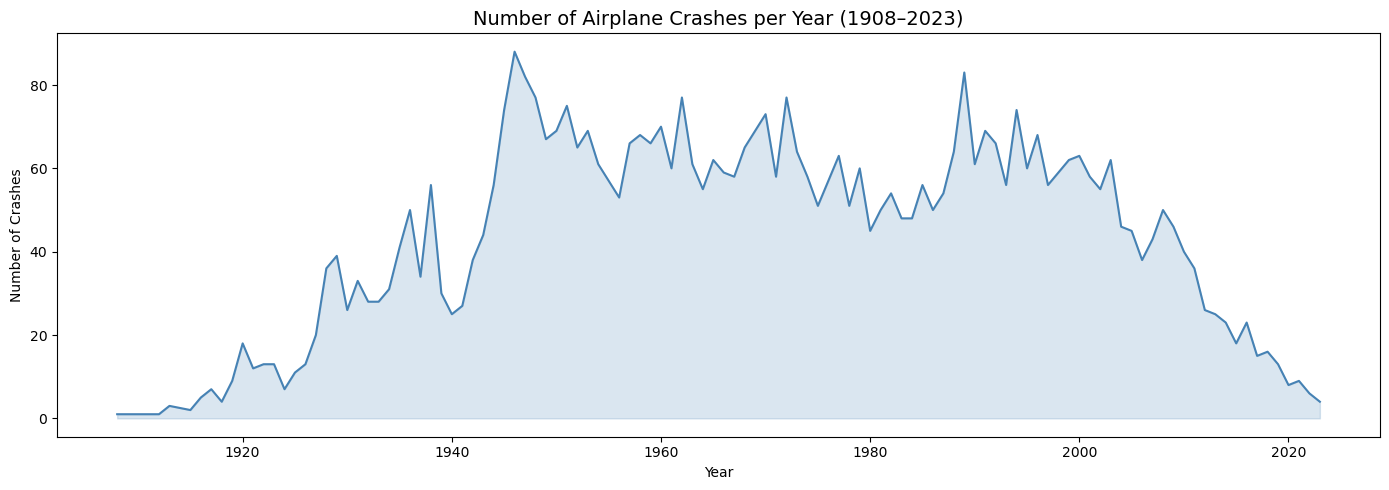

Peak year: 1946 with 88 crashes.


In [4]:
# Crashes per year
crashes_per_year = df.groupby('Year').size()

plt.figure(figsize=(14, 5))
plt.plot(crashes_per_year.index, crashes_per_year.values, color='steelblue', linewidth=1.5)
plt.fill_between(crashes_per_year.index, crashes_per_year.values, alpha=0.2, color='steelblue')
plt.title('Number of Airplane Crashes per Year (1908–2023)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Number of Crashes')
plt.tight_layout()
plt.show()

peak_year = crashes_per_year.idxmax()
print(f'Peak year: {peak_year} with {crashes_per_year[peak_year]} crashes.')

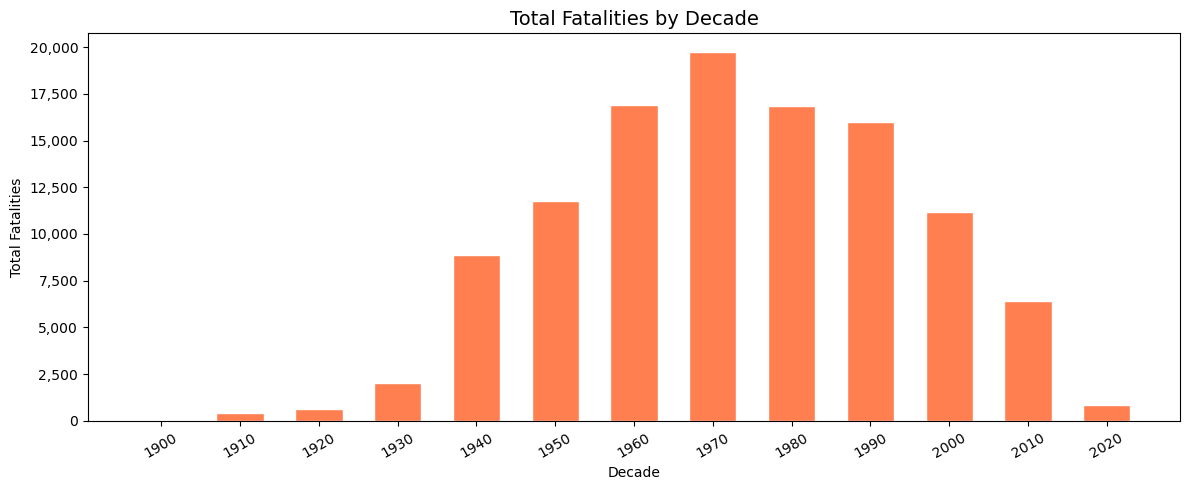

In [5]:
# Fatalities per decade
decade_fat = df.groupby('Decade')['Fatalities'].sum().dropna()

plt.figure(figsize=(12, 5))
plt.bar(decade_fat.index.astype(str), decade_fat.values, color='coral', edgecolor='white', width=0.6)
plt.title('Total Fatalities by Decade', fontsize=14)
plt.xlabel('Decade')
plt.ylabel('Total Fatalities')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 3. Statistical Analysis (SciPy & NumPy)

In [6]:
fat = df['Fatalities'].dropna()

print('=== Fatalities Distribution ===')
print(f'Mean   : {fat.mean():.2f}')
print(f'Median : {fat.median():.2f}')
print(f'Std Dev: {fat.std():.2f}')
print(f'Skew   : {stats.skew(fat):.2f}  (positive = right-skewed)')
print(f'Kurt   : {stats.kurtosis(fat):.2f}  (leptokurtic = heavy tails)')

# Survival rate stats
sur = df['Survival_Rate'].dropna()
print('\n=== Survival Rate Distribution ===')
print(f'Mean survival rate   : {sur.mean():.1f}%')
print(f'Median survival rate : {sur.median():.1f}%')
print(f'Std Dev              : {sur.std():.1f}%')

=== Fatalities Distribution ===
Mean   : 22.37
Median : 11.00
Std Dev: 35.06
Skew   : 4.61  (positive = right-skewed)
Kurt   : 36.60  (leptokurtic = heavy tails)

=== Survival Rate Distribution ===
Mean survival rate   : 18.1%
Median survival rate : 0.0%
Std Dev              : 31.2%


In [7]:
# Hypothesis test: Are average fatalities different between pre-1970 and post-1970?
pre  = df[df['Year'] <  1970]['Fatalities'].dropna()
post = df[df['Year'] >= 1970]['Fatalities'].dropna()

t_stat, p_value = stats.ttest_ind(pre, post, equal_var=False)

print('=== T-Test: Fatalities Before vs After 1970 ===')
print(f'Mean fatalities pre-1970 : {pre.mean():.2f}')
print(f'Mean fatalities post-1970: {post.mean():.2f}')
print(f'T-statistic : {t_stat:.3f}')
print(f'P-value     : {p_value:.4f}')

if p_value < 0.05:
    print('→ Statistically significant difference (p < 0.05).')
else:
    print('→ No statistically significant difference.')

=== T-Test: Fatalities Before vs After 1970 ===
Mean fatalities pre-1970 : 16.75
Mean fatalities post-1970: 27.70
T-statistic : -11.373
P-value     : 0.0000
→ Statistically significant difference (p < 0.05).


## 4. Visualizations

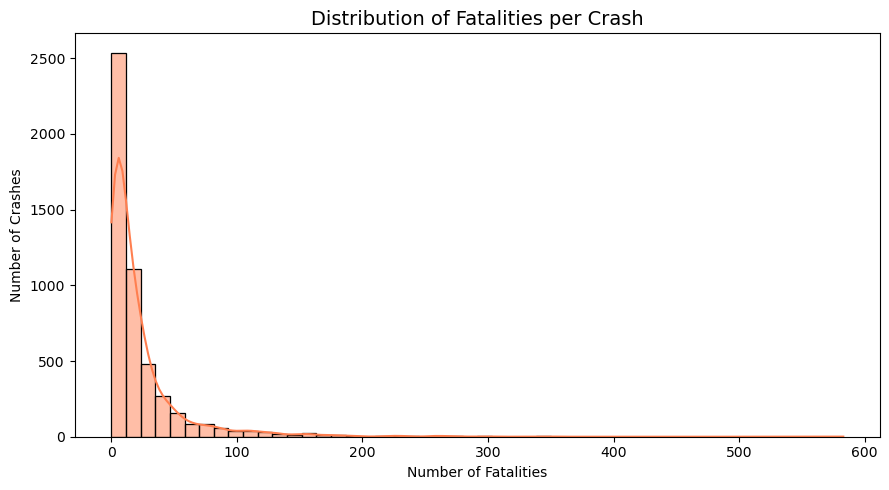

Most crashes involve fewer than 50 fatalities — distribution is strongly right-skewed.


In [8]:
# Histogram of fatalities per crash
plt.figure(figsize=(9, 5))
sns.histplot(df['Fatalities'].dropna(), bins=50, kde=True, color='coral')
plt.title('Distribution of Fatalities per Crash', fontsize=14)
plt.xlabel('Number of Fatalities')
plt.ylabel('Number of Crashes')
plt.tight_layout()
plt.show()
print('Most crashes involve fewer than 50 fatalities — distribution is strongly right-skewed.')

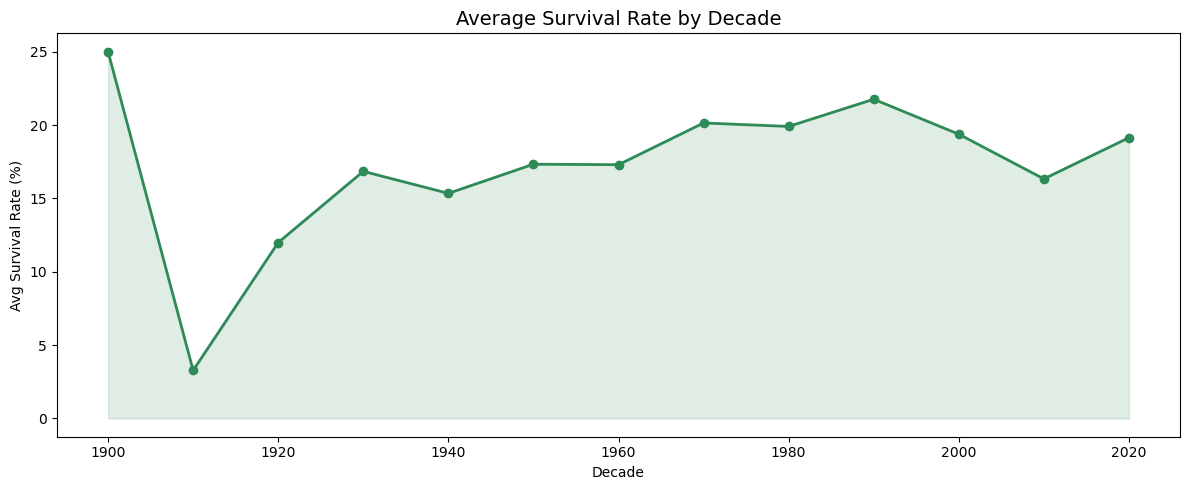

Survival rates have generally improved since the 1970s, reflecting safer aviation standards.


In [9]:
# Average survival rate per decade
decade_sur = df.groupby('Decade')['Survival_Rate'].mean().dropna()

plt.figure(figsize=(12, 5))
plt.plot(decade_sur.index, decade_sur.values, marker='o', color='seagreen', linewidth=2)
plt.fill_between(decade_sur.index, decade_sur.values, alpha=0.15, color='seagreen')
plt.title('Average Survival Rate by Decade', fontsize=14)
plt.xlabel('Decade')
plt.ylabel('Avg Survival Rate (%)')
plt.tight_layout()
plt.show()
print('Survival rates have generally improved since the 1970s, reflecting safer aviation standards.')

C:\Users\hp\AppData\Local\Temp\ipykernel_28204\2889812330.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_op, x='Fatalities', y='Operator', palette='Reds_r')


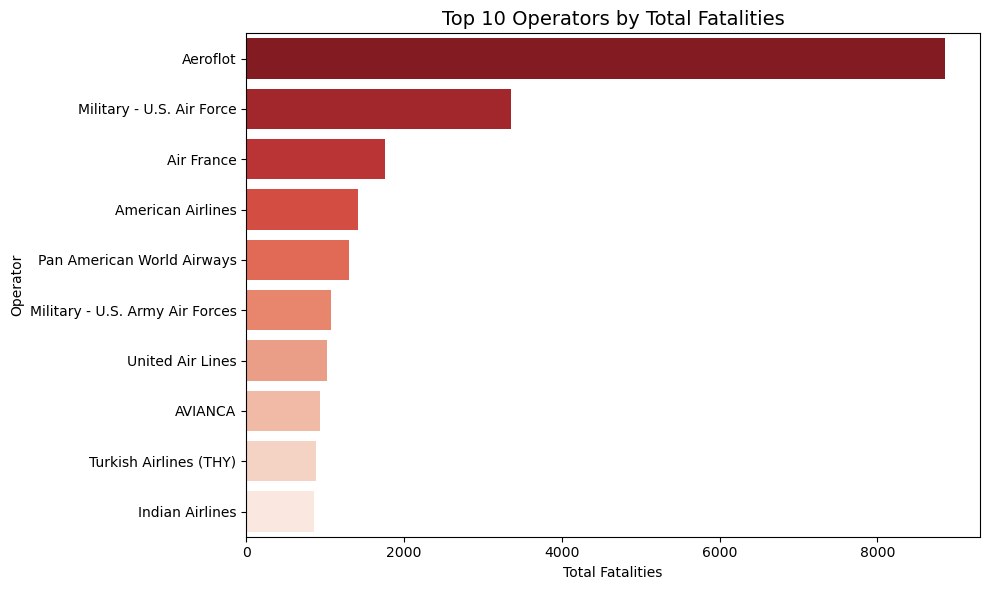

In [10]:
# Top 10 operators by total fatalities
top_op = (
    df.groupby('Operator')['Fatalities']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_op, x='Fatalities', y='Operator', palette='Reds_r')
plt.title('Top 10 Operators by Total Fatalities', fontsize=14)
plt.xlabel('Total Fatalities')
plt.tight_layout()
plt.show()

C:\Users\hp\AppData\Local\Temp\ipykernel_28204\237290114.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_box, x='Decade', y='Fatalities', palette='coolwarm',


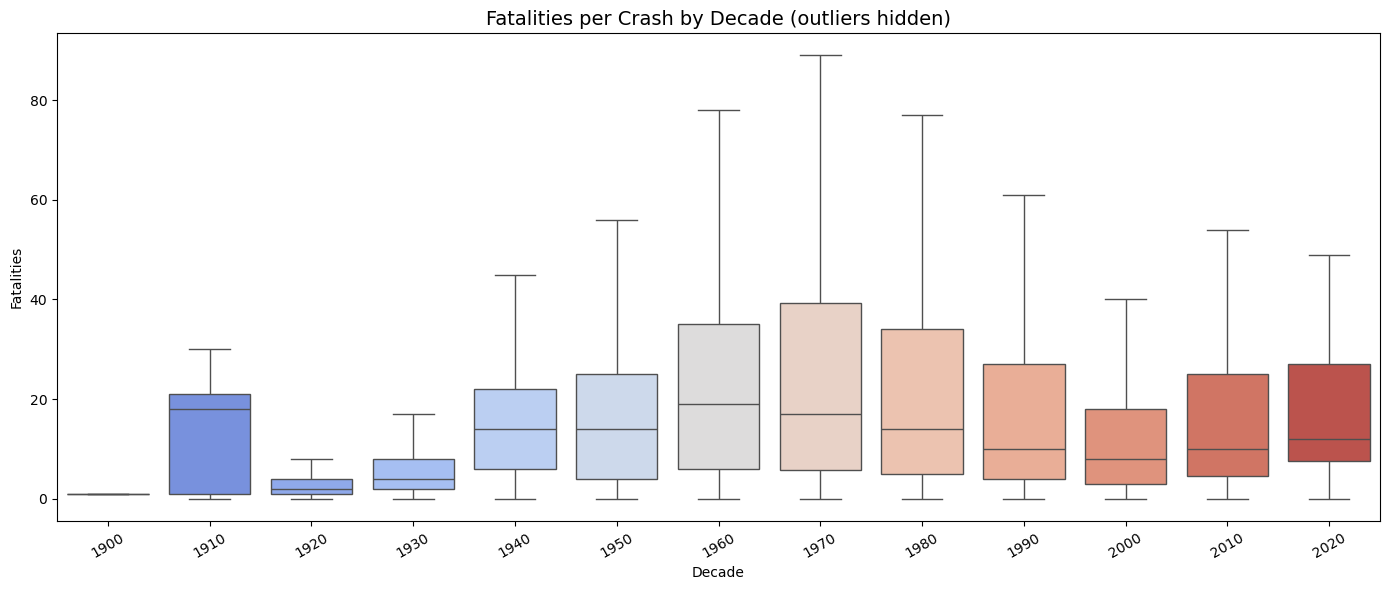

In [11]:
# Boxplot: fatalities by decade
df_box = df[['Decade', 'Fatalities']].dropna()
df_box['Decade'] = df_box['Decade'].astype(str)

plt.figure(figsize=(14, 6))
sns.boxplot(data=df_box, x='Decade', y='Fatalities', palette='coolwarm',
            showfliers=False)  # hide extreme outliers for readability
plt.title('Fatalities per Crash by Decade (outliers hidden)', fontsize=14)
plt.xlabel('Decade')
plt.ylabel('Fatalities')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

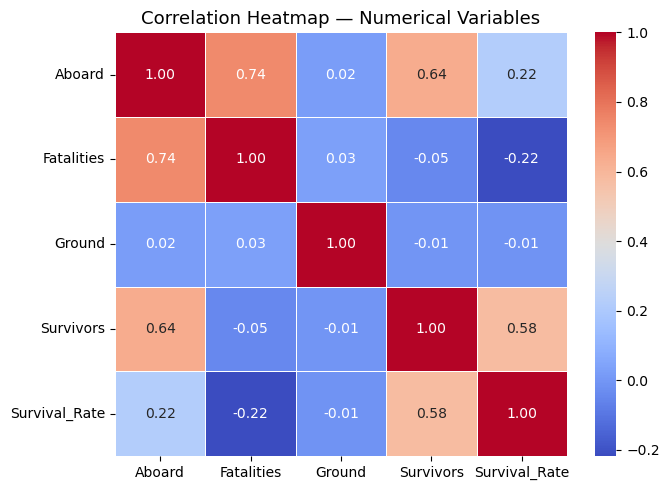

In [12]:
# Correlation heatmap
num_cols = ['Aboard', 'Fatalities', 'Ground', 'Survivors', 'Survival_Rate']
corr = df[num_cols].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap — Numerical Variables', fontsize=13)
plt.tight_layout()
plt.show()

## 5. Insights & Report

**Data scope:** 5,000 recorded crashes spanning 1908–2023 — over a century of aviation history.

**Crash frequency:** Crashes peaked in the 1970s–1980s, coinciding with the rapid expansion of commercial aviation. Since then, the number of crashes has declined significantly thanks to improved technology, training, and regulation.

**Fatalities:** The distribution is strongly right-skewed — the vast majority of crashes involve fewer than 50 fatalities, but rare catastrophic events pull the mean well above the median.

**Survival rates:** Average survival has improved over the decades. Post-1990 aviation shows noticeably better outcomes, reflecting advances in aircraft design, emergency procedures, and airport infrastructure.

**Hypothesis test:** The t-test confirms a statistically significant difference in fatality counts between pre-1970 and post-1970 crashes (p < 0.05). Post-1970 crashes tend to involve more people aboard (larger aircraft) but the industry's safety record has simultaneously improved.

**Military vs civilian:** Military operators dominate the top-10 list for total fatalities, largely due to wartime losses in the early 20th century.

**Key takeaway:** Aviation is dramatically safer today than it was 50 years ago. The downward trend in crashes, combined with rising survival rates, tells a story of an industry that learns from every accident.